In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

cal_housing_data_train = pd.read_csv('/content/sample_data/california_housing_train.csv')
cal_housing_data_test = pd.read_csv('/content/sample_data/california_housing_test.csv')
cal_housing_data_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [8]:
cal_housing_data_test.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0


#NUMPY Implementation

#All 8 features in both train and test


In [9]:
X_train = cal_housing_data_train.drop('median_house_value', axis=1).values
y_train = cal_housing_data_train['median_house_value'].values
X_test = cal_housing_data_test.drop('median_house_value', axis=1).values
y_test = cal_housing_data_test['median_house_value'].values

#How to standardize all 8 features and add a bias term?

In [13]:
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
X_train_std = (X_train - mu)/sigma
X_test_std = (X_test - mu)/sigma

#Adding bias
X_train_aug = np.c_[np.ones((X_train_std.shape[0],1)), X_train_std]
X_test_aug = np.c_[np.ones((X_test_std.shape[0],1)), X_test_std]

#Multivariate gradient descent with Numpy

In [138]:
from sklearn.metrics import mean_squared_error
import numpy as np

n_samples, n_features = X_train_aug.shape
W = np.zeros(n_features)

lr = 0.25
epochs = 100
losses = []

for epoch in range(epochs):
  y_pred = X_train_aug.dot(W)
  error = y_pred - y_train
  mse = mean_squared_error(y_train, y_pred)
  losses.append(mse)

  #Gradient:

  gradient = (2/n_samples) * (X_train_aug.T.dot(error))

  #Update:

  W -= lr * gradient

  if epoch % 10 == 0:
    print(f'Epoch {epoch}, MSE: {mse}')

Epoch 0, MSE: 56425110555.93047
Epoch 10, MSE: 5499744800.657717
Epoch 20, MSE: 5130928677.406453
Epoch 30, MSE: 4970336237.288054
Epoch 40, MSE: 4897570045.279976
Epoch 50, MSE: 4863378026.358744
Epoch 60, MSE: 4846670104.642197
Epoch 70, MSE: 4838124352.017064
Epoch 80, MSE: 4833512473.439772
Epoch 90, MSE: 4830867805.871065


#Check if the training converged

Text(0, 0.5, 'MSE')

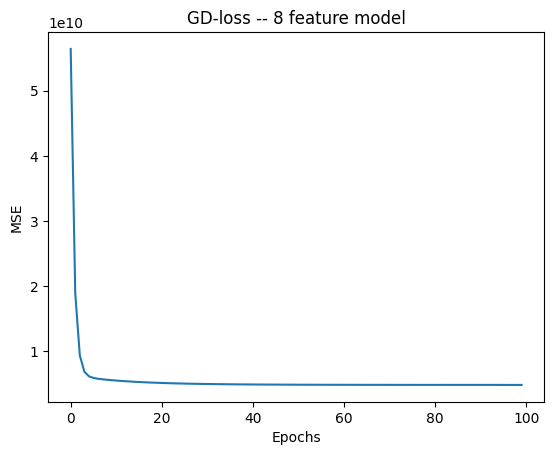

In [139]:
plt.plot(losses)
plt.title("GD-loss -- 8 feature model")
plt.xlabel('Epochs')
plt.ylabel('MSE')

#Model performance on unseen data

In [140]:
y_pred_test_np = X_test_aug.dot(W)

rmse_np = np.sqrt(mean_squared_error(y_test, y_pred_test_np))
mae_np = mean_absolute_error(y_test, y_pred_test_np)
r2_np = r2_score(y_test, y_pred_test_np)

print(f'RMSE: {rmse_np}')
print(f'MAE: {mae_np}')
print(f'R2: {r2_np}')

RMSE: 69766.25639374502
MAE: 50292.70832395891
R2: 0.6194959924840916


#SCIKIT-LEARN Implementation

In [141]:
linreg = LinearRegression(fit_intercept=True)
linreg.fit(X_train_std, y_train)

y_pred_test_sklearn = linreg.predict(X_test_std)

rmse_sklearn = np.sqrt(mean_squared_error(y_test, y_pred_test_sklearn))
mae_sklearn = mean_absolute_error(y_test, y_pred_test_sklearn)
r2_sklearn = r2_score(y_test, y_pred_test_sklearn)

print(f'RMSE: {rmse_sklearn}')
print(f'MAE: {mae_sklearn}')
print(f'R2: {r2_sklearn}')

RMSE: 69765.36022216805
MAE: 50352.228257942894
R2: 0.6195057678311999


#Compare both implementations

In [142]:
print(f'RMSE_diff: {rmse_np - rmse_sklearn}')
print(f'MAE_diff: {mae_np - mae_sklearn}')
print(f'R2_diff: {r2_np - r2_sklearn}')

RMSE_diff: 0.8961715769692091
MAE_diff: -59.5199339839819
R2_diff: -9.775347108331722e-06
